## Comparison of 2D neural network with 1D

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets, Put
from binomial_tree.binomial_tree import BinomialTree

In [2]:
exercise_type = 'american'

In [3]:
n_assets = 2

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5])
correlation_matrix = np.array([
    [1.0, 0.6],
    [0.6, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 4.0
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=n_assets, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [4]:
input_size = n_assets + 1
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
loss_weights = {
    'pde': 2.0,
    'exercise': 1.0,
    'boundary_Smax': 10.0,
    'boundary_Smin': 0.1,
}

In [6]:
put_product = PutProductMultipleAssets()
trainer_product = GeneralTrainer(model_config, market_params, put_product, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)
trainer_product.train(batch_size=1000, epochs=10000, tol=1e-6)

Iteration 0, Loss: 7.2693939208984375
Iteration 100, Loss: 0.6296384930610657
Iteration 200, Loss: 0.08198734372854233
Iteration 300, Loss: 0.04172194004058838
Iteration 400, Loss: 0.020682090893387794
Iteration 500, Loss: 0.022955164313316345
Iteration 600, Loss: 0.02116074599325657
Iteration 700, Loss: 0.015814267098903656
Iteration 800, Loss: 0.013916543684899807
Iteration 900, Loss: 0.012909556739032269
Iteration 1000, Loss: 0.010594744235277176
Iteration 1100, Loss: 0.009552625007927418
Iteration 1200, Loss: 0.010235323570668697
Iteration 1300, Loss: 0.011860515922307968
Early stopping at epoch 1373


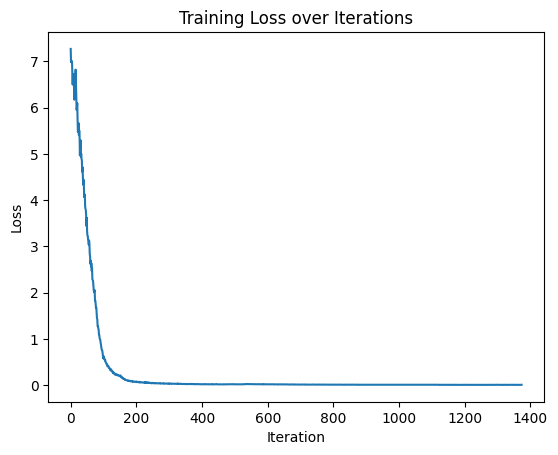

In [7]:
trainer_product.plot_losses()

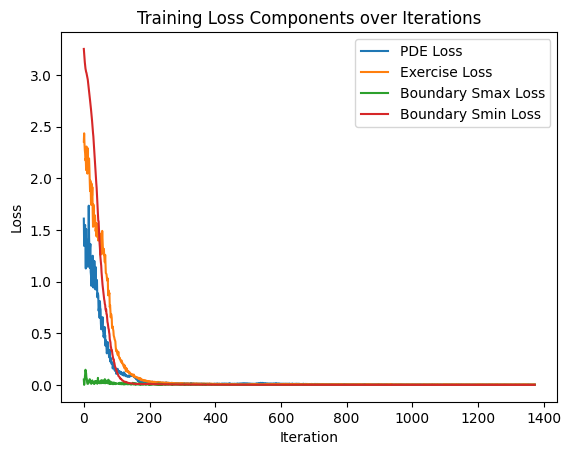

In [8]:
trainer_product.plot_losses_detailed()

In [9]:
trainer_product.predict(1, 2, 2).item()

0.49988043308258057

## Compare with 1D case

Iteration 0, Loss: 2.128946304321289
Iteration 100, Loss: 0.03747723251581192
Iteration 200, Loss: 0.005145121365785599
Iteration 300, Loss: 0.0010998414363712072
Iteration 400, Loss: 0.00048197468277066946
Iteration 500, Loss: 0.0002482192066963762
Iteration 600, Loss: 0.00017282029148191214
Iteration 700, Loss: 0.00016461995255667716
Iteration 800, Loss: 0.00013298082922119647
Iteration 900, Loss: 9.900188888423145e-05
Iteration 1000, Loss: 8.065493602771312e-05
Iteration 1100, Loss: 9.854578820522875e-05
Iteration 1200, Loss: 8.790684660198167e-05
Iteration 1300, Loss: 9.784547728486359e-05
Early stopping at epoch 1393


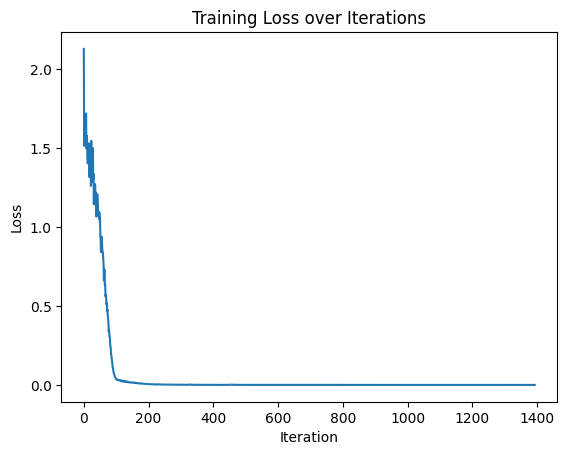

In [10]:
r_prime = n_assets * r + np.sum(np.tril(sigma, k=-1))
sigma_prime = np.sqrt(np.sum(sigma))

market_params_1d = MarketParams(
    n_assets=1,
    S0=S0**n_assets,
    r=r_prime,
    sigma=sigma_prime,
    K=K,
    T=T,
    S_min=S_min**n_assets,
    S_max=S_max**n_assets
)
put_1d = Put()

bt_1d = BinomialTree(market_params_1d, n_steps=200)

model_config_1d = ModelConfig(
    input_size=2,
    hidden_sizes=[32, 64, 32],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=0.001
)

loss_weights_1d = {
    'pde': 1.0,
    'exercise': 1.0,
    'boundary_Smax': 1.0,
    'boundary_Smin': 0.05,
}

trainer_1d = GeneralTrainer(model_config_1d, market_params_1d, put_1d, exercise_type=exercise_type, loss_weights=loss_weights_1d, seed=67)
trainer_1d.train(batch_size=1000, epochs=10000, tol=1e-6)
trainer_1d.plot_losses()

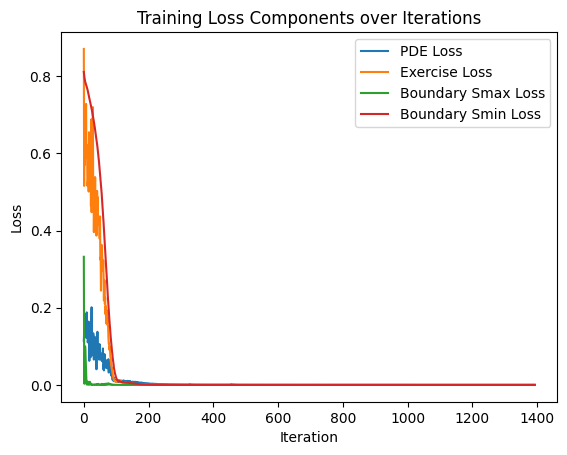

In [11]:
trainer_1d.plot_losses_detailed()

In [12]:
as1 = np.array([2, 2])
print(trainer_product.predict(1, *as1).item())
print(trainer_1d.predict(1, np.prod(as1)).item())

0.49988043308258057
0.02636815421283245


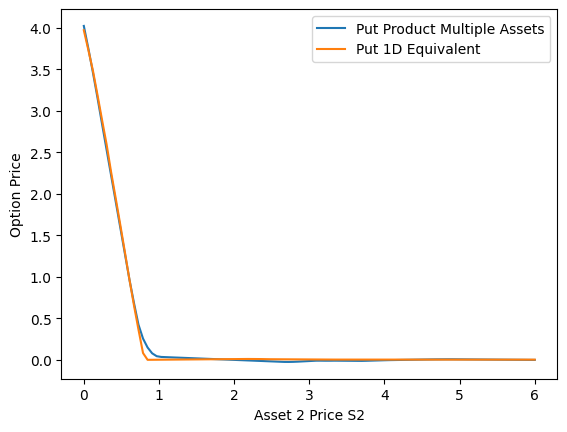

In [13]:
b = 100

t = np.full(b, 0.0)
s1 = np.full(b, 5.0)
s2 = np.linspace(0.0, 6.0, b)

putproduct = trainer_product.predict(t, s1, s2).detach().numpy()
put1d = trainer_1d.predict(t, s1 * s2).detach().numpy()
plt.plot(s2, putproduct, label='Put Product Multiple Assets')
plt.plot(s2, put1d, label='Put 1D Equivalent')
plt.xlabel('Asset 2 Price S2')
plt.ylabel('Option Price')
plt.legend()
plt.show()

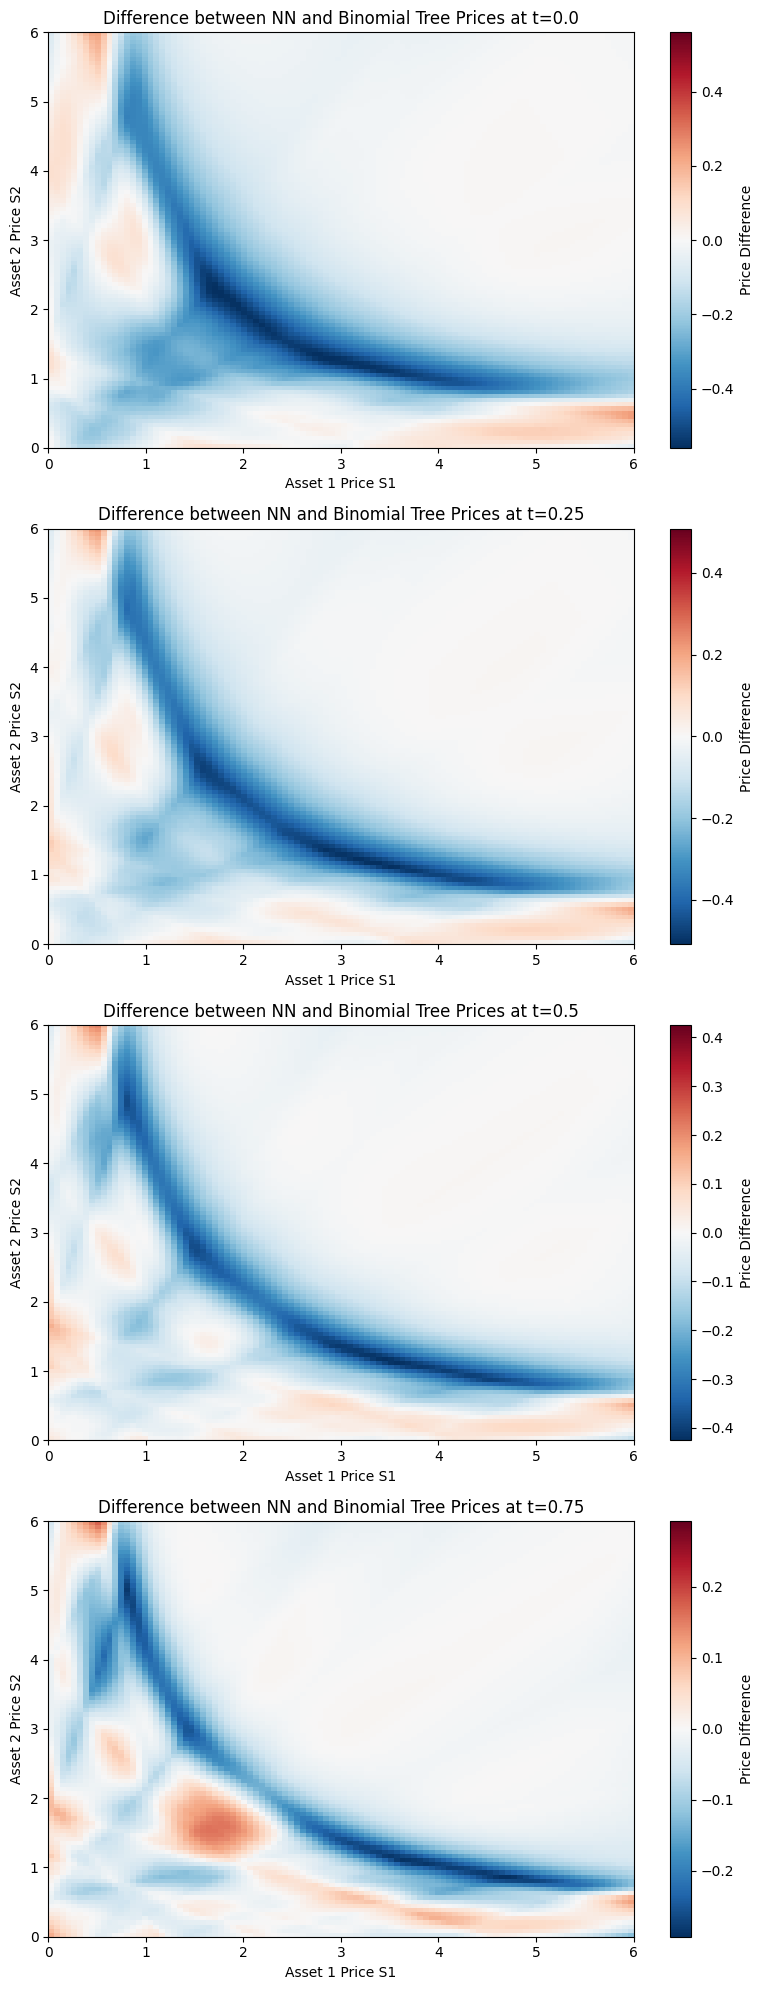

In [14]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 6.0, resolution)
S2 = np.linspace(0.0, 6.0, resolution)

ts = [0.0, 0.25, 0.5, 0.75]

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    prices_2d = trainer_product.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
    # prices_1d = trainer_1d.predict(t_grid.flatten(), (S1_grid * S2_grid).flatten()).detach().numpy().reshape(S1_grid.shape)
    prices_1d = bt_1d.predict(t, (S1_grid * S2_grid).flatten()).reshape(S1_grid.shape)

    diff = prices_2d - prices_1d

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(diff).max()
    vmin = -vmax
    im = plt.imshow(diff, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price Difference')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'Difference between NN and Binomial Tree Prices at t={t}')
plt.tight_layout()
plt.show()